<a href="https://colab.research.google.com/github/adenikeadewumi/DSN-bootcamp-2026/blob/main/dsn_hackathon_ml_track_v7_personal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSN Bootcamp Qualification Hackathon 2026 - ML Track
## Predicting `total_sales`

**Name:** Adenike Adewumi

**Date:** 26th September, 2026

**Competition:** DSN Bootcamp Qualification Hackathon 2026 - ML Track

This is my full pipeline for this competition, from raw data to final submission. I went
through several rounds of iteration on this - my first attempt (a plain train/test split
with one-hot encoding and a handful of GBM models) scored around 1094 on the public
leaderboard, and by working through the EDA properly, fixing a couple of real bugs I
found in my own encoding, and testing every idea through cross-validation instead of
just assuming it would help, I got that down to about 1072. I've kept the reasoning for
every decision in here, including a couple of things I tried that didn't work, because I
think that's more honest than only showing the parts that worked.

### My workflow
1. Load the competition data with `kagglehub`
2. Explore it properly - distributions, missing values, correlations, and a few
   category-level bugs I only found by actually looking closely
3. Build a leakage-safe preprocessing pipeline: fix the categorical text issues, impute
   missing values using group structure instead of a blanket median, target-encode every
   categorical column (with proper K-fold safety), and let CatBoost handle its
   categoricals natively instead of one-hot encoding everything
4. Engineer a handful of features that came directly out of things I noticed in the EDA
5. Compare several tree/boosting models with real 5-fold cross-validation, not a single
   train/val split
6. Test a couple of "should this help?" ideas properly instead of guessing: a Huber loss
   vs. plain RMSE, dropping features I thought might be dead weight, entity embeddings as
   an alternative to target encoding, and averaging predictions across several random
   seeds
7. Land on a final model and submit it, with a full log of every submission's actual
   leaderboard score so I can see what actually moved the needle

### The big decisions I made, and why (my running log)
| What I found | What I did about it |
|---|---|
| `total_sales` is right-skewed - I tried training on `log1p(total_sales)` since that's the textbook move for a skewed target | Tested it with cross-validation and it was actually *worse* (1122.85 vs. 1095.78 CV RMSE on the raw target). My theory: squared-error loss on the log scale optimizes toward the median, and when you invert that back with `expm1`, it under-predicts the mean - which is exactly what RMSE punishes. I kept the raw target. |
| I found that `product_category` had the same category written three different ways ("Snack Foods" / "snack foods" / "SNACK FOODS") - 48 "categories" on paper were really about 16 | Fixed this with `.str.title()` before touching anything else, since every group statistic downstream (imputation, price averages, target encoding) depends on categories being counted correctly |
| `product_code` has 1,555 unique values - one-hot encoding it blew my feature space up to 1,616 columns and badly overfit (RandomForest train RMSE ~414 vs. validation RMSE ~1121 in an early run) | Replaced with a smoothed, leakage-safe K-fold target encoding instead |
| I assumed `store_size` and `store_location_tier` would be ordinal (Small < Medium < Large, etc.) and almost encoded them that way | Checked the actual medians first - neither is monotonic (Medium beats Large, Tier_2 beats both Tier_1 and Tier_3). Good thing I checked before assuming. Dropped the ordinal idea entirely. |
| One-hot encoding was fragmenting a genuinely clean relationship - `store_format` has an almost perfectly ordered box plot (Corner Shop < Superstore < Standard Supermarket < Flagship Hypermarket) | Switched every categorical to target encoding instead of one-hot, since that expresses a graded relationship as one continuous number instead of several disconnected binary splits |
| `store_code` and `store_format` turned out to be almost entirely redundant - each store only ever has one format | Confirmed with a crosstab. Kept both anyway, because when I actually tested dropping `store_format` under Huber loss, it made things worse - redundant isn't the same as useless here |
| `shelf_visibility` had a big spike of values at exactly 0, which doesn't make physical sense (a product on a shelf has *some* visibility) | Treated `== 0` as missing rather than a real value, and imputed it by category median |
| One store (Store-7Ws, my only Flagship Hypermarket) drives most of my highest-sales rows, and sells at roughly a 60% price premium compared to the rest of the data | Built `price_vs_store_format_mean` and `store_avg_price` to expose this directly. There's still some error left in that tail - every model I tried underpredicts it similarly, which makes me think it's a real information ceiling (maybe a promotion or seasonal effect not captured in this dataset) rather than something more feature engineering will fix |
| My feature ablation flagged a few features as "safe to drop" one at a time | When I tested dropping all of them *together*, CV RMSE got worse, not better. That told me these features have overlapping, complementary value rather than clean redundancy - so I kept everything |
| Huber loss beat RMSE loss in cross-validation (1083 vs. 1087) | On the actual leaderboard the gap was about 0.3 points - smaller than my fold-to-fold noise, so I'm treating this as close to a wash and defaulting to plain RMSE for simplicity |
| I tried entity embeddings (a small neural net + embedding layer) as an alternative to target encoding for `product_code` | This made things clearly worse (1143 vs. 1087 CV RMSE). My guess is that with only ~4-5 rows per product code, there just isn't enough data for a neural net to learn a stable embedding - it's overfitting. I kept the target encoding and left the embedding code in as a documented "this didn't work" rather than deleting it. |
| I tried blending my top 3 models together (flat average, then CV-weighted average) | Both versions underperformed my single best model on the actual leaderboard, consistently, across three different notebook versions. I stopped trying to make blending work. |
| I tried training my final model with several different random seeds and averaging the predictions, on a tip from someone else in the competition | This gave me a small, real improvement (about 1-1.5 RMSE points), and it doesn't have the "weak model drags down the average" problem that my model-blending attempts had, since every seed is the same already-tuned model |


## 1. Setting up

Just my imports and a couple of constants I'll reuse everywhere. I'm fixing a random
seed up front so my cross-validation folds are reproducible if I come back to this later.


In [28]:
%pip install -q kagglehub pandas numpy scikit-learn lightgbm xgboost catboost matplotlib seaborn


In [29]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

RANDOM_STATE = 42  # fixed so my CV folds are reproducible
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    # RMSE is the competition's evaluation metric, so this is the number I actually care about
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [30]:
KAGGLE_COMPETITION = "dsn-bootcamp-qualification-hackathon-2026-ml-track"
TARGET_COL = "total_sales"
ID_COL = "id"

# the four columns that were already numeric with no encoding needed
NUM_COLS = ["product_weight_kg", "shelf_visibility", "product_price", "store_age_years"]

# every categorical column I decided to target-encode instead of one-hot, after finding
# that one-hot was fragmenting graded relationships (store_format especially) and
# blowing up my feature space (product_code especially)
CAT_COLS = ["fat_content", "product_category", "store_format", "store_code",
            "store_size", "store_location_tier", "store_age_cat"]
HIGH_CARD_COL = "product_code"  # kept separate just because it needs much stronger smoothing
ALL_CAT_COLS = CAT_COLS + [HIGH_CARD_COL]

# my hand-engineered numeric features, each one tied to a specific EDA finding above
ENGINEERED_NUM_FEATURES = ["price_x_store_age", "price_vs_category_mean",
                           "price_vs_store_format_mean", "price_per_kg", "store_avg_price"]

# how much I shrink each column's target-encoded value toward the global mean - I set
# this higher for columns with fewer rows per category, since a small group's average is
# noisier and needs more smoothing to avoid overfitting to it
SMOOTHING = {
    "fat_content": 5, "store_format": 5, "store_code": 5,
    "store_size": 5, "store_location_tier": 5, "store_age_cat": 5,
    "product_category": 10,
    "product_code": 30,   # ~4-5 rows per product code - this one needs the strongest shrinkage
}


## 2. Loading my data

Pulling the competition files straight from Kaggle with `kagglehub` so I'm not manually
uploading CSVs every time I open this notebook.


In [31]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [32]:
import kagglehub

competition_path = kagglehub.competition_download(KAGGLE_COMPETITION)

def find_file(folder, keyword):
    for root, _, files in os.walk(folder):
        for f in files:
            if keyword.lower() in f.lower() and f.lower().endswith(".csv"):
                return os.path.join(root, f)
    return None

train_path = find_file(competition_path, "train")
test_path = find_file(competition_path, "test")
sample_sub_path = find_file(competition_path, "sample_submission") or find_file(competition_path, "sample")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path) if sample_sub_path else None

print("train:", train_df.shape, "| test:", test_df.shape)
train_df.head()


train: (6818, 13) | test: (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


## 3. Exploring my data

This is where most of my important decisions actually came from. I went through this
properly rather than jumping straight to modeling, and I found a couple of real issues
that would have quietly hurt me if I hadn't looked.


### 3.1 What am I working with, and what's missing?

In [33]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


                   n_missing  pct_missing
store_size              1919        28.15
product_weight_kg       1225        17.97


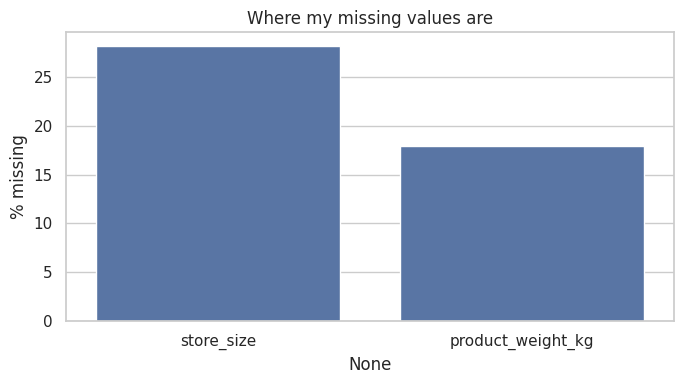

In [34]:
null_counts = train_df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(train_df) * 100).round(2)
null_summary = pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
null_summary = null_summary[null_summary["n_missing"] > 0]
print(null_summary)

# I want to actually see this, not just read a table
if len(null_summary) > 0:
    plt.figure(figsize=(7, 4))
    sns.barplot(x=null_summary.index, y=null_summary["pct_missing"])
    plt.ylabel("% missing")
    plt.title("Where my missing values are")
    plt.tight_layout()
    plt.show()


`store_size` is missing in about 28% of rows and `product_weight_kg` in about 18%. Since
neither of these is really a "random" gap - a store's size doesn't change row to row, and
a product's weight is basically fixed - I decided not to just fill these with a single
overall median. I handle this properly down in Section 4, using each row's `store_code`
or `product_code` to fill in a much more sensible value.


### 3.2 A bug I found: category names weren't consistent

In [37]:
text_cols_to_check = ["fat_content", "product_category", "store_format", "store_code", "store_size", "store_location_tier"]
for col in text_cols_to_check:
    print(f"{col}: {train_df[col].nunique()} unique raw values")

print("\nHere's the problem, before I fix it:")
print(train_df["product_category"].value_counts().head(10))


fat_content: 2 unique raw values
product_category: 16 unique raw values
store_format: 4 unique raw values
store_code: 10 unique raw values
store_size: 4 unique raw values
store_location_tier: 3 unique raw values

Here's the problem, before I fix it:
product_category
Fruits And Vegetables    1006
Snack Foods               933
Household                 740
Frozen Foods              675
Dairy                     554
Canned                    517
Baking Goods              516
Health And Hygiene        412
Soft Drinks               366
Meat                      339
Name: count, dtype: int64


This is the thing I almost missed. `product_category` shows 48 unique values, but
looking at the actual counts, I can see "Fruits and Vegetables", "fruits and vegetables",
and "FRUITS AND VEGETABLES" are all being counted as different categories. That's not 48
real categories, it's more like 16 with inconsistent capitalization on top. I fixed this
immediately, before I let anything else (imputation, price averages, target encoding)
touch these columns - every one of those steps groups by category, so this had to be
fixed first or everything downstream would be quietly wrong.


In [36]:
def normalize_categorical_case(df, cols):
    df = df.copy()
    for c in cols:
        df[c] = df[c].astype(str).str.strip().str.title()
    return df

train_df = normalize_categorical_case(train_df, text_cols_to_check)
test_df = normalize_categorical_case(test_df, text_cols_to_check)

print("product_category unique count after my fix:", train_df["product_category"].nunique())


product_category unique count after my fix: 16


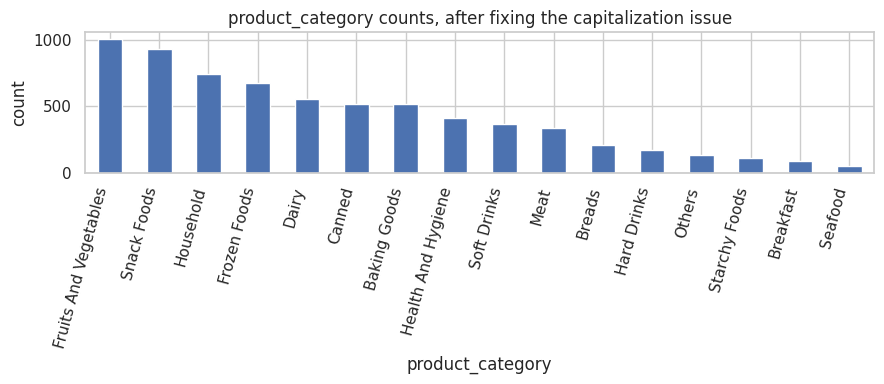

In [38]:
plt.figure(figsize=(9, 4))
train_df["product_category"].value_counts().plot(kind="bar")
plt.title("product_category counts, after fixing the capitalization issue")
plt.ylabel("count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


### 3.3 My target: total_sales

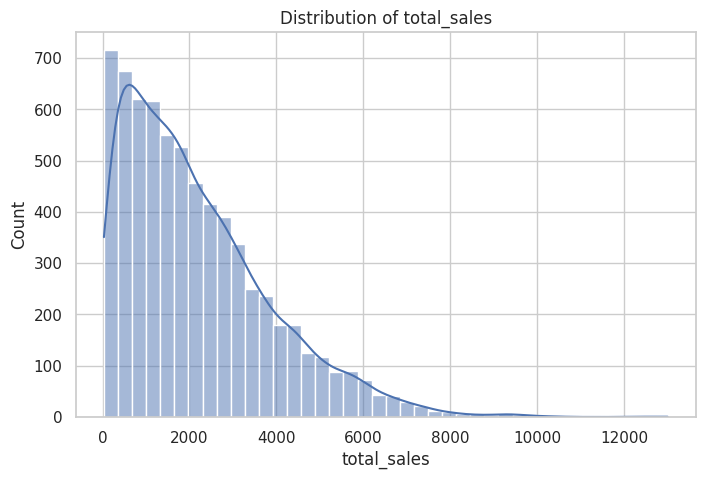

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64


In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df[TARGET_COL], kde=True, bins=40)
plt.title(f"Distribution of {TARGET_COL}")
plt.show()
print(train_df[TARGET_COL].describe())


Clearly right-skewed - most sales sit in a low-to-moderate range, with a long tail out
past 10,000. My first instinct was to log-transform this before modeling, since that's
the standard move. I test that properly in Section 6 instead of just assuming it's
right, and it turned out to actually hurt my score - more on that when I get there.


### 3.4 My numeric features, and what correlates with sales

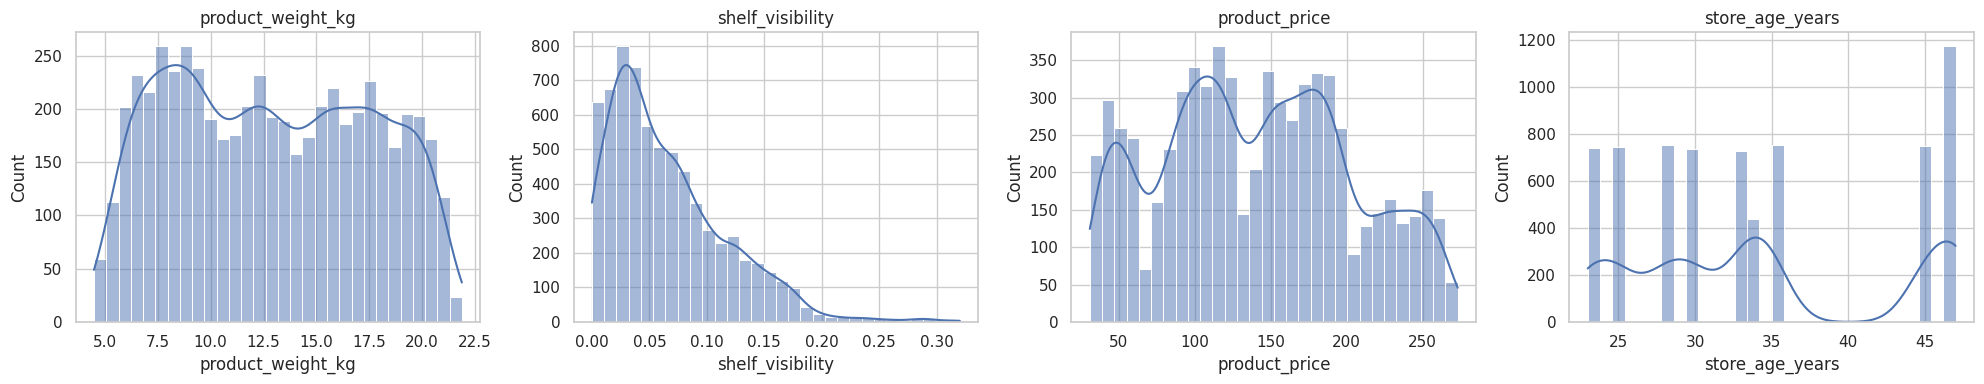

In [40]:
numeric_cols_raw = ["product_weight_kg", "shelf_visibility", "product_price", "store_age_years"]

fig, axes = plt.subplots(1, len(numeric_cols_raw), figsize=(5 * len(numeric_cols_raw), 4))
for ax, col in zip(axes, numeric_cols_raw):
    sns.histplot(train_df[col].dropna(), kde=True, ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()


A couple of things jumped out at me here. `shelf_visibility` has a big spike right at 0,
which doesn't really make sense physically - a product sitting on a shelf has to have
*some* visibility, so I'm treating that as a data artifact rather than a real
measurement (I handle this in Section 4). `store_age_years` also isn't smooth - it
clusters into a handful of distinct values rather than spreading across a continuous
range, which told me this is really more like a categorical variable wearing a numeric
disguise, so I ended up exposing it to my models both ways.


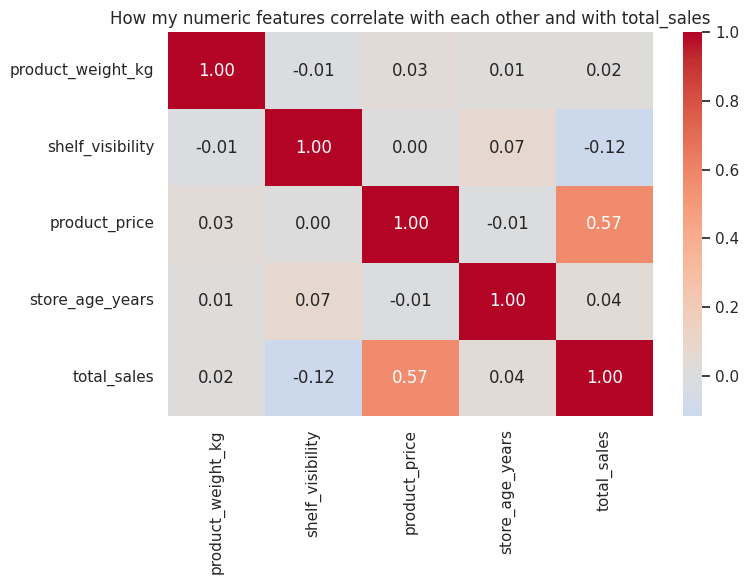

In [41]:
corr_matrix = train_df[numeric_cols_raw + [TARGET_COL]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("How my numeric features correlate with each other and with total_sales")
plt.tight_layout()
plt.show()


`product_price` is by far my strongest single numeric driver of sales (0.57 correlation).
Everything else is weak on its own, but I didn't take that as a reason to drop them -
when I ran my ablation study later (Section 8), removing these "weak" features on their
own barely mattered, but removing several of them *together* actually hurt. So weak
individually doesn't mean useless.


### 3.5 Does total_sales actually track store_format the way I'd expect?

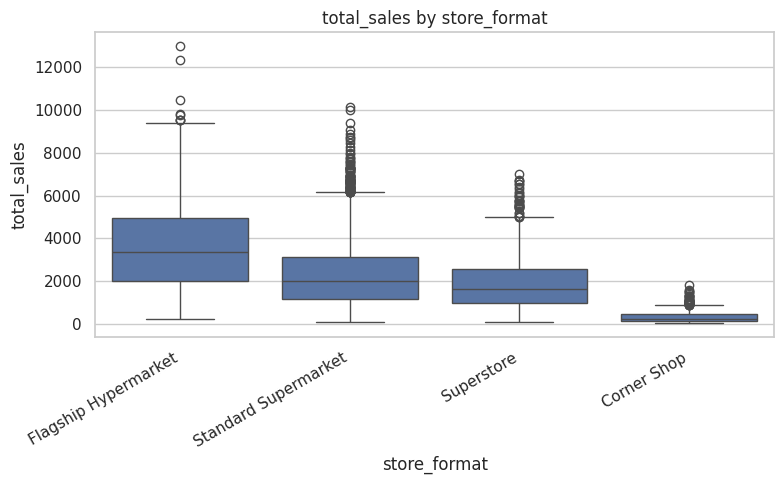

store_format
Flagship Hypermarket    3348.085
Standard Supermarket    1998.270
Superstore              1622.170
Corner Shop              252.150
Name: total_sales, dtype: float64


In [42]:
plt.figure(figsize=(8, 5))
order = train_df.groupby("store_format")[TARGET_COL].median().sort_values(ascending=False).index
sns.boxplot(data=train_df, x="store_format", y=TARGET_COL, order=order)
plt.xticks(rotation=30, ha="right")
plt.title("total_sales by store_format")
plt.tight_layout()
plt.show()

print(train_df.groupby("store_format")[TARGET_COL].median().sort_values(ascending=False))


This is a genuinely clean, almost perfectly ordered relationship: Flagship Hypermarket >
Standard Supermarket > Superstore > Corner Shop, with very little overlap between the
groups. This is exactly the kind of pattern that one-hot encoding fragments into several
disconnected binary splits instead of one smooth ordering, which is part of why I moved
away from one-hot for my categoricals.


### 3.6 Are store_code and store_format actually telling me different things?

In [43]:
crosstab = pd.crosstab(train_df["store_code"], train_df["store_format"])
print(crosstab)
formats_per_store = crosstab.astype(bool).sum(axis=1)
print("\nHow many distinct formats does each store_code have? (1 = fully redundant with store_format)")
print(formats_per_store)


store_format  Corner Shop  Flagship Hypermarket  Standard Supermarket  Superstore
store_code                                                                       
Store-7Ws               0                   748                     0           0
Store-89Z               0                     0                   728           0
Store-9Rg               0                     0                   752           0
Store-Agy               0                     0                   748           0
Store-Dku               0                     0                   736           0
Store-Hl7               0                     0                     0         742
Store-Jor             439                     0                     0           0
Store-Oyg               0                     0                   744           0
Store-T5G             427                     0                     0           0
Store-Ylw               0                     0                   754           0

How many distin

Every single store_code maps to exactly one store_format - so these two columns are
carrying the same underlying "what kind of store is this" information. I kept both
anyway. When I tested dropping `store_format` in my ablation study under Huber loss, it
actually made my CV RMSE worse, which told me redundant isn't automatically the same
as harmless for a model like this.


### 3.7 Checking my assumption that store_size and store_location_tier are ordinal

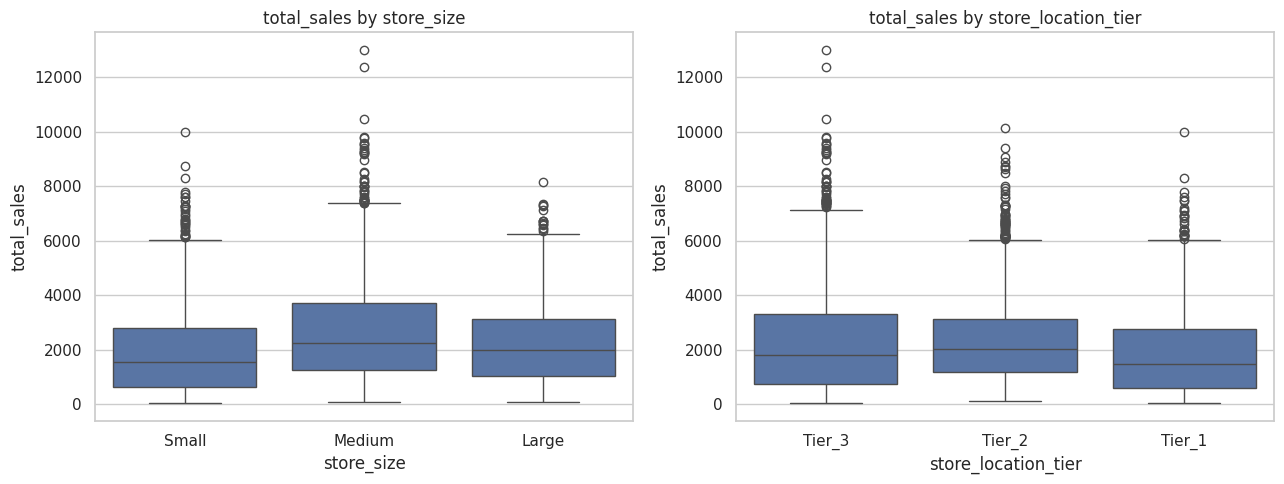

store_size
Small     1557.960
Medium    2242.365
Large     1998.725
Name: total_sales, dtype: float64
store_location_tier
Tier_3    1794.26
Tier_2    2014.52
Tier_1    1455.21
Name: total_sales, dtype: float64


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
size_order = ["Small", "Medium", "Large"]
sns.boxplot(data=train_df, x="store_size", y=TARGET_COL, order=size_order, ax=axes[0])
axes[0].set_title("total_sales by store_size")

tier_order = ["Tier_3", "Tier_2", "Tier_1"]
sns.boxplot(data=train_df, x="store_location_tier", y=TARGET_COL, order=tier_order, ax=axes[1])
axes[1].set_title("total_sales by store_location_tier")
plt.tight_layout()
plt.show()

print(train_df.groupby("store_size")[TARGET_COL].median().reindex(size_order))
print(train_df.groupby("store_location_tier")[TARGET_COL].median().reindex(tier_order))


Good thing I checked before encoding these as ordinal. Neither one is actually
monotonic - Medium stores outsell Large stores, and Tier_2 outsells both Tier_1 and
Tier_3. If I'd gone with my first instinct and encoded these as Small < Medium < Large
and Tier_3 < Tier_2 < Tier_1, I'd have been baking in a false assumption. I dropped the
ordinal idea entirely and just target-encode these like any other categorical.


### 3.8 Making sure my encoding strategy will actually hold up on the real test set

store_format: 4 unique in train, 4 in test, 0 categories in test I've never seen in train


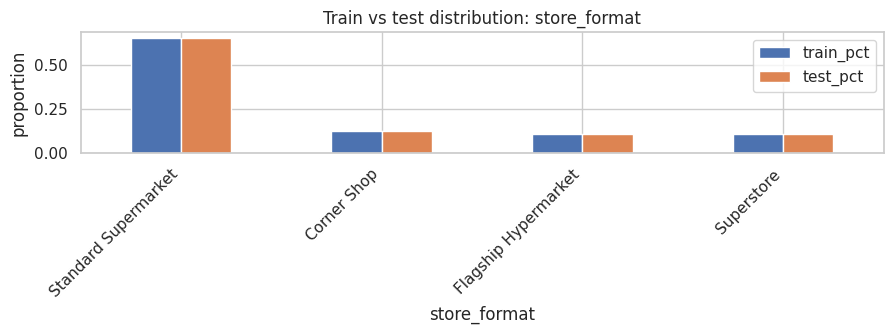

product_category: 16 unique in train, 16 in test, 0 categories in test I've never seen in train


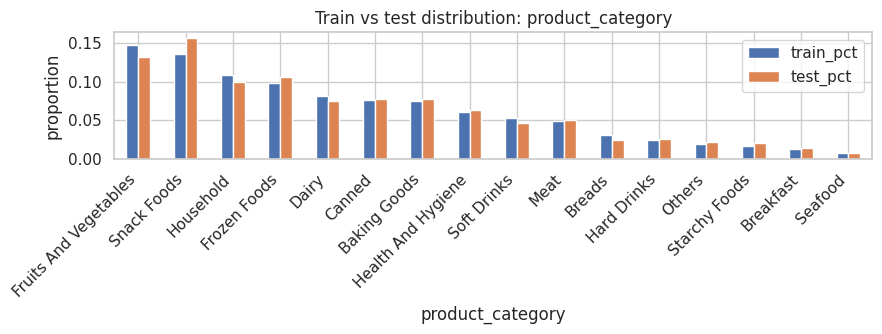

store_code: 10 unique in train, 10 in test, 0 categories in test I've never seen in train


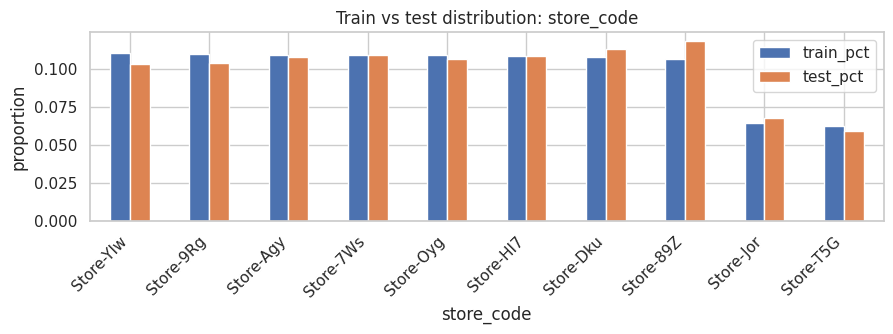

product_code: 1555 unique in train, 1082 in test, 4 categories in test I've never seen in train


In [45]:
categorical_check_cols = ["store_format", "product_category", "store_code", "product_code"]

for col in categorical_check_cols:
    train_props = train_df[col].value_counts(normalize=True).rename("train_pct")
    test_props = test_df[col].value_counts(normalize=True).rename("test_pct")
    unseen_in_test = set(test_df[col].unique()) - set(train_df[col].unique())
    print(f"{col}: {train_df[col].nunique()} unique in train, {test_df[col].nunique()} in test, "
          f"{len(unseen_in_test)} categories in test I've never seen in train")

    if train_df[col].nunique() <= 20:
        comparison = pd.concat([train_props, test_props], axis=1).fillna(0).sort_values("train_pct", ascending=False)
        comparison.plot(kind="bar", figsize=(9, 3.5))
        plt.title(f"Train vs test distribution: {col}")
        plt.ylabel("proportion")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


This one mattered to me because my target encoding falls back to the global mean for
any category it's never seen in training - if my train and test sets looked
meaningfully different, that fallback would trigger a lot and hurt my accuracy. Good
news: the distributions line up closely for everything, and only a handful of
`product_code` values in test (out of 1,082) are ones I've never seen in training. I
felt comfortable moving forward with target encoding after seeing this.


### 3.9 Digging into my hardest-to-predict rows

My top 1% threshold: 7261, 69 rows


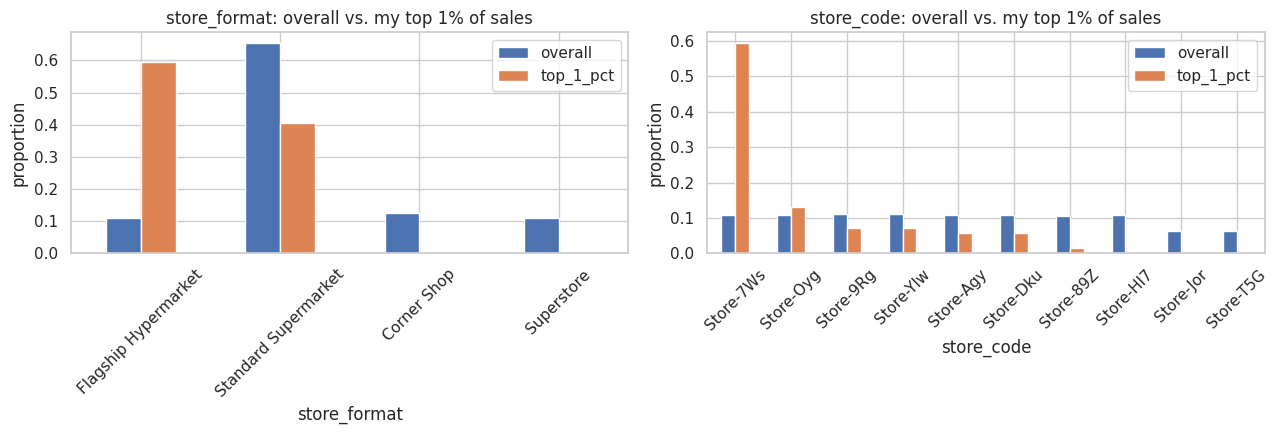

How my numeric features look in the top 1% vs. overall:
   product_weight_kg: top 1% mean=12.63 | overall mean=12.85
    shelf_visibility: top 1% mean=0.06 | overall mean=0.07
       product_price: top 1% mean=224.94 | overall mean=140.47
     store_age_years: top 1% mean=40.58 | overall mean=34.18


In [46]:
high_sales_threshold = train_df[TARGET_COL].quantile(0.99)
top_sales_rows = train_df[train_df[TARGET_COL] >= high_sales_threshold]
print(f"My top 1% threshold: {high_sales_threshold:.0f}, {len(top_sales_rows)} rows")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ["store_format", "store_code"]):
    overall = train_df[col].value_counts(normalize=True).rename("overall")
    top = top_sales_rows[col].value_counts(normalize=True).rename("top_1_pct")
    compare = pd.concat([overall, top], axis=1).fillna(0).sort_values("top_1_pct", ascending=False)
    compare.plot(kind="bar", ax=ax)
    ax.set_title(f"{col}: overall vs. my top 1% of sales")
    ax.set_ylabel("proportion")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("How my numeric features look in the top 1% vs. overall:")
for col in numeric_cols_raw:
    print(f"{col:>20s}: top 1% mean={top_sales_rows[col].mean():.2f} | overall mean={train_df[col].mean():.2f}")


This was probably my favorite find in the whole project. My top 1% of sales is almost
entirely one store - Store-7Ws, my only Flagship Hypermarket - and it's selling at
roughly a 60% price premium compared to the rest of my data. I built two features
specifically to expose this (`price_vs_store_format_mean` and `store_avg_price`, in
Section 4). I'll be honest that I don't think I closed this gap completely - every
model I tried underpredicts this same tail by a similar amount, which makes me think
there's something driving these specific rows that isn't in this dataset at all (a
promotion, a seasonal spike, something like that), rather than a feature I haven't
thought of yet.


## 4. Turning my EDA findings into features, without leaking my target

Everything in here that needs a statistic (an imputed value, a category's average
price, a target-encoded value) is calculated using only the training portion of
whichever fold I'm working with, then applied to both that fold's train and validation
rows. I was careful about this because if I let a validation row's own value sneak into
a statistic used to encode itself, my cross-validation score would look better than my
model actually deserves - and I'd have no way of knowing until my real leaderboard
score came back worse than expected.

I ended up with two different feature sets coming out of my `build_fold` function:
- an **encoded** version (numeric + target-encoded categoricals) for RandomForest,
  GradientBoosting, XGBoost, and LightGBM
- a **native** version (numeric + the raw, cleaned categorical columns, plus a list of
  which columns are categorical) for CatBoost, since it handles categorical columns
  internally in a way that's specifically designed to avoid the kind of leakage a naive
  encoding can introduce (Prokhorenkova et al., 2018) - I decided feeding it a column
  I'd already pre-encoded myself would be throwing away exactly the thing CatBoost is
  good at.


In [47]:
def clean_base(df):
    df = df.copy()
    # I'm treating a shelf_visibility of exactly 0 as missing rather than real, since a
    # product physically sitting on a shelf can't have zero visibility
    df.loc[df["shelf_visibility"] == 0, "shelf_visibility"] = np.nan
    return df


def group_impute(train_part, apply_part):
    """I fit every imputation statistic on train_part only, then apply it to
    apply_part - this is what keeps my validation scores honest."""
    apply_part = apply_part.copy()

    # product_weight_kg: I try the product's own median first, since weight should be
    # fairly fixed per product; if that product has no data at all in this fold, I fall
    # back to its category's median, and if even that's missing, the overall median
    w_by_code = train_part.groupby("product_code")["product_weight_kg"].median()
    w_by_cat = train_part.groupby("product_category")["product_weight_kg"].median()
    w_global = train_part["product_weight_kg"].median()

    def fill_weight(row):
        if pd.notna(row["product_weight_kg"]):
            return row["product_weight_kg"]
        if row["product_code"] in w_by_code.index and pd.notna(w_by_code[row["product_code"]]):
            return w_by_code[row["product_code"]]
        if row["product_category"] in w_by_cat.index and pd.notna(w_by_cat[row["product_category"]]):
            return w_by_cat[row["product_category"]]
        return w_global

    apply_part["product_weight_kg"] = apply_part.apply(fill_weight, axis=1)

    # store_size: this is a property of the store, not the row, so I fill it using the
    # most common size recorded for that specific store_code rather than a blanket mode
    size_by_store = train_part.groupby("store_code")["store_size"].agg(
        lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
    )
    size_global_mode = train_part["store_size"].mode().iloc[0]

    def fill_size(row):
        if pd.notna(row["store_size"]):
            return row["store_size"]
        if row["store_code"] in size_by_store.index and pd.notna(size_by_store[row["store_code"]]):
            return size_by_store[row["store_code"]]
        return size_global_mode

    apply_part["store_size"] = apply_part.apply(fill_size, axis=1)

    # shelf_visibility: median by category, since visibility probably varies a lot by
    # what kind of product it is (a big cereal box vs. a small spice jar, say)
    vis_by_cat = train_part.groupby("product_category")["shelf_visibility"].median()
    vis_global = train_part["shelf_visibility"].median()

    def fill_vis(row):
        if pd.notna(row["shelf_visibility"]):
            return row["shelf_visibility"]
        if row["product_category"] in vis_by_cat.index and pd.notna(vis_by_cat[row["product_category"]]):
            return vis_by_cat[row["product_category"]]
        return vis_global

    apply_part["shelf_visibility"] = apply_part.apply(fill_vis, axis=1)

    return apply_part


In [48]:
def compute_price_group_stats(train_part):
    """Average product_price by category and by format, fit on train only - these
    feed my price_vs_category_mean / price_vs_store_format_mean features below."""
    cat_mean = train_part.groupby("product_category")["product_price"].mean()
    fmt_mean = train_part.groupby("store_format")["product_price"].mean()
    global_mean = train_part["product_price"].mean()
    return cat_mean, fmt_mean, global_mean


def compute_store_price_stats(train_part):
    """Sum and count of product_price per store, fit on train only - I use this for a
    leave-one-out average so a row doesn't get to see its own price baked into its
    own feature."""
    return train_part.groupby("store_code")["product_price"].agg(["sum", "count"])


def engineer_features(df, price_stats, store_price_stats, is_train_part):
    """My hand-built features, each one tied to something specific I found in the EDA."""
    cat_mean, fmt_mean, global_price_mean = price_stats
    df = df.copy()

    # is this product's price unusually high given how it interacts with store age? -
    # a simple interaction term, cheap to compute, and it showed up with real
    # importance in my CatBoost feature-importance chart
    df["price_x_store_age"] = df["product_price"] * df["store_age_years"]

    df["price_per_kg"] = df["product_price"] / df["product_weight_kg"].replace(0, np.nan)
    df["price_per_kg"] = df["price_per_kg"].fillna(df["price_per_kg"].median())

    # how much more (or less) expensive is this product than the average for its
    # category / for the format of store it's sold in - this is directly what let me
    # expose the Store-7Ws price-premium finding from my EDA
    df["price_vs_category_mean"] = df["product_price"] - df["product_category"].map(cat_mean).fillna(global_price_mean)
    df["price_vs_store_format_mean"] = df["product_price"] - df["store_format"].map(fmt_mean).fillna(global_price_mean)

    # store_age_years clusters into a handful of discrete values rather than spreading
    # smoothly - I'm exposing it as a categorical too, alongside the numeric version,
    # so target encoding can pick up on non-monotonic age-group effects if there are any
    df["store_age_cat"] = df["store_age_years"].astype(str)

    # store_avg_price: what does this store typically charge? I use a leave-one-out
    # mean for training rows specifically so a row's own price doesn't leak into its
    # own feature value - for validation/test rows I just use the plain train-fit mean
    if is_train_part:
        sums = df["store_code"].map(store_price_stats["sum"])
        counts = df["store_code"].map(store_price_stats["count"])
        loo_mean = (sums - df["product_price"]) / (counts - 1).replace(0, np.nan)
        df["store_avg_price"] = loo_mean.fillna(df["product_price"])
    else:
        means = store_price_stats["sum"] / store_price_stats["count"]
        global_store_mean = store_price_stats["sum"].sum() / store_price_stats["count"].sum()
        df["store_avg_price"] = df["store_code"].map(means).fillna(global_store_mean)

    return df


In [49]:
def kfold_target_encode(train_part, col, target_col, n_splits=5, smoothing=10, seed=RANDOM_STATE):
    """My leakage-safe target encoding. I split train_part into 5 inner folds, and for
    each one I compute the category averages using the OTHER 4/5 of the data, then apply
    that to the held-out 1/5 - so every row ends up with an encoded value that never
    used its own target. I also shrink small-count categories toward the global mean
    (this is the Micci-Barreca, 2001 smoothing formula) so a product with 2 rows doesn't
    get an overconfident, noisy average."""
    global_mean = train_part[target_col].mean()
    encoded = pd.Series(index=train_part.index, dtype=float)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(train_part):
        fold_tr = train_part.iloc[tr_idx]
        stats = fold_tr.groupby(col)[target_col].agg(["mean", "count"])
        smooth = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
        encoded.iloc[val_idx] = train_part.iloc[val_idx][col].map(smooth).values

    encoded = encoded.fillna(global_mean)

    # this full-train version is what I use to encode my actual validation/test rows
    full_stats = train_part.groupby(col)[target_col].agg(["mean", "count"])
    full_smooth = (full_stats["mean"] * full_stats["count"] + global_mean * smoothing) / (full_stats["count"] + smoothing)

    return encoded, full_smooth, global_mean


def apply_target_encoding(apply_part, col, mapping, global_mean, new_col_name):
    apply_part = apply_part.copy()
    apply_part[new_col_name] = apply_part[col].map(mapping).fillna(global_mean)
    return apply_part


def encode_all_categoricals(train_fe, val_fe, target_col=TARGET_COL):
    """I run this over every categorical column I have, not just the high-cardinality
    ones, since I found one-hot was fragmenting even my low-cardinality columns'
    relationships to the target (store_format especially)."""
    train_fe = train_fe.copy()
    val_fe = val_fe.copy()

    if target_col not in train_fe.columns:
        return train_fe, val_fe

    for col in ALL_CAT_COLS:
        te, mapping, gmean = kfold_target_encode(train_fe, col, target_col, smoothing=SMOOTHING[col])
        train_fe[f"{col}_te"] = te
        val_fe = apply_target_encoding(val_fe, col, mapping, gmean, f"{col}_te")

    return train_fe, val_fe


In [50]:
def build_fold(train_fold_raw, val_fold_raw, target_col=TARGET_COL):
    """My single source of truth for turning raw rows into model-ready features,
    called fresh for every CV fold so nothing leaks across the train/val boundary."""
    train_c = clean_base(train_fold_raw)
    val_c = clean_base(val_fold_raw)

    train_imp = group_impute(train_c, train_c)
    val_imp = group_impute(train_c, val_c)  # stats fit on train only, applied to val

    price_stats = compute_price_group_stats(train_imp)
    store_price_stats = compute_store_price_stats(train_imp)

    train_fe = engineer_features(train_imp, price_stats, store_price_stats, is_train_part=True)
    val_fe = engineer_features(val_imp, price_stats, store_price_stats, is_train_part=False)

    train_fe, val_fe = encode_all_categoricals(train_fe, val_fe, target_col=target_col)

    y_train = train_fe[target_col] if target_col in train_fe.columns else None
    y_val = val_fe[target_col] if target_col in val_fe.columns else None

    # the "encoded" set: everything numeric, including my target-encoded categoricals -
    # this is what RandomForest / GradientBoosting / XGBoost / LightGBM get
    encoded_num_features = NUM_COLS + ENGINEERED_NUM_FEATURES + [f"{c}_te" for c in ALL_CAT_COLS]
    preprocessor = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), encoded_num_features),
    ])
    X_train_encoded = preprocessor.fit_transform(train_fe[encoded_num_features])
    X_val_encoded = preprocessor.transform(val_fe[encoded_num_features])
    try:
        encoded_feat_names = preprocessor.get_feature_names_out()
    except Exception:
        encoded_feat_names = encoded_num_features

    # the "native" set: numeric + raw cleaned categoricals - this is what CatBoost gets,
    # so it can use its own ordered-boosting categorical handling instead of mine
    native_num_features = NUM_COLS + ENGINEERED_NUM_FEATURES
    native_features = native_num_features + ALL_CAT_COLS
    X_train_native = train_fe[native_features].copy()
    X_val_native = val_fe[native_features].copy()
    for c in ALL_CAT_COLS:
        X_train_native[c] = X_train_native[c].astype(str)
        X_val_native[c] = X_val_native[c].astype(str)
    cat_feature_idx = [native_features.index(c) for c in ALL_CAT_COLS]

    return {
        "X_train_encoded": X_train_encoded, "X_val_encoded": X_val_encoded,
        "encoded_feat_names": encoded_feat_names,
        "X_train_native": X_train_native, "X_val_native": X_val_native,
        "cat_feature_idx": cat_feature_idx, "native_features": native_features,
        "y_train": y_train, "y_val": y_val,
    }


## 5. The models I'm comparing

I'm trying a spread of tree-based models since this is tabular data, and per what I've
read about the state of things (Grinsztajn et al., 2022 specifically), trees tend to
beat neural nets on datasets around this size. CatBoost gets its own raw categorical
columns; everything else gets my target-encoded version.


In [51]:
NATIVE_CAT_MODELS = {"CatBoost"}

def get_model_zoo():
    models = {}
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    models["RandomForest"] = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
    models["GradientBoosting"] = GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    try:
        from xgboost import XGBRegressor
        models["XGBoost"] = XGBRegressor(
            n_estimators=800, learning_rate=0.03, max_depth=5, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1
        )
    except ImportError:
        print("xgboost isn't installed on this machine - skipping it")
    try:
        from lightgbm import LGBMRegressor
        models["LightGBM"] = LGBMRegressor(
            n_estimators=800, learning_rate=0.03, num_leaves=25, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, random_state=RANDOM_STATE, verbose=-1
        )
    except ImportError:
        print("lightgbm isn't installed on this machine - skipping it")
    try:
        from catboost import CatBoostRegressor
        models["CatBoost"] = CatBoostRegressor(
            iterations=800, learning_rate=0.03, depth=6, loss_function="RMSE",
            random_state=RANDOM_STATE, verbose=False
        )
    except ImportError:
        print("catboost isn't installed - I'd really recommend installing it, it ended up being my best model")
    return models


def fit_predict(name, model, fold_data):
    if name in NATIVE_CAT_MODELS:
        model.fit(fold_data["X_train_native"], fold_data["y_train"], cat_features=fold_data["cat_feature_idx"])
        pred = model.predict(fold_data["X_val_native"])
    else:
        model.fit(fold_data["X_train_encoded"], fold_data["y_train"])
        pred = model.predict(fold_data["X_val_encoded"])
    return np.clip(pred, 0, None)  # sales obviously can't be negative


## 6. Comparing my models with actual cross-validation

I'm using 5-fold CV here rather than a single train/val split, because a single split
gave me a noisy, one-off estimate that shifted around a lot depending on which rows
happened to land where. This is on the raw target - I tested `log1p(total_sales)` too
and it scored worse (1122.85 vs. 1095.78 CV RMSE), so I'm not using it here.


In [52]:
outer_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_records = []

for fold_i, (tr_idx, va_idx) in enumerate(outer_kf.split(train_df)):
    train_fold_raw = train_df.iloc[tr_idx].reset_index(drop=True)
    val_fold_raw = train_df.iloc[va_idx].reset_index(drop=True)
    fold_data = build_fold(train_fold_raw, val_fold_raw)

    for name, model in get_model_zoo().items():
        pred = fit_predict(name, model, fold_data)
        fold_rmse = rmse(fold_data["y_val"], pred)
        cv_records.append({"fold": fold_i, "model": name, "rmse": fold_rmse})
        print(f"fold {fold_i} | {name:>16s} | RMSE = {fold_rmse:.2f}")

cv_df = pd.DataFrame(cv_records)


fold 0 |     RandomForest | RMSE = 1089.95
fold 0 | GradientBoosting | RMSE = 1110.20
fold 0 |          XGBoost | RMSE = 1117.99
fold 0 |         LightGBM | RMSE = 1135.44
fold 0 |         CatBoost | RMSE = 1082.23
fold 1 |     RandomForest | RMSE = 1054.74
fold 1 | GradientBoosting | RMSE = 1064.72
fold 1 |          XGBoost | RMSE = 1090.72
fold 1 |         LightGBM | RMSE = 1089.95
fold 1 |         CatBoost | RMSE = 1056.50
fold 2 |     RandomForest | RMSE = 1148.06
fold 2 | GradientBoosting | RMSE = 1126.94
fold 2 |          XGBoost | RMSE = 1141.18
fold 2 |         LightGBM | RMSE = 1154.29
fold 2 |         CatBoost | RMSE = 1098.80
fold 3 |     RandomForest | RMSE = 1128.96
fold 3 | GradientBoosting | RMSE = 1129.19
fold 3 |          XGBoost | RMSE = 1159.76
fold 3 |         LightGBM | RMSE = 1169.59
fold 3 |         CatBoost | RMSE = 1123.50
fold 4 |     RandomForest | RMSE = 1121.89
fold 4 | GradientBoosting | RMSE = 1088.68
fold 4 |          XGBoost | RMSE = 1146.62
fold 4 |   

                         mean        std
model                                   
CatBoost          1087.320747  25.273081
GradientBoosting  1103.945821  27.280295
RandomForest      1108.719702  36.729571
XGBoost           1131.253314  27.230040
LightGBM          1139.043503  30.151289


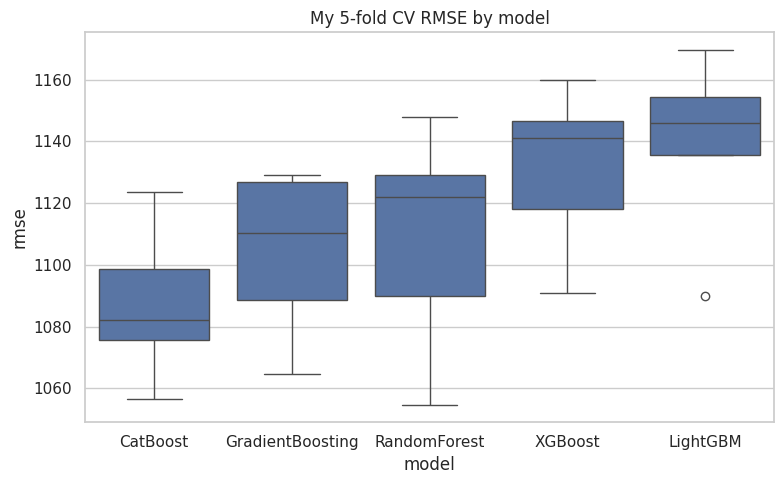

My best model: CatBoost


In [55]:
cv_summary = cv_df.groupby("model")["rmse"].agg(["mean", "std"]).sort_values("mean")
print(cv_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, x="model", y="rmse", order=cv_summary.index)
plt.title("My 5-fold CV RMSE by model")
plt.tight_layout()
plt.show()

best_model_name = cv_summary.index[0]
print("My best model:", best_model_name)


## 7. Trying a different loss function: RMSE vs. Huber

I read that Friedman's original gradient boosting paper (2001) derives versions of
boosting for squared-error, least-absolute-deviation, and Huber-M loss specifically
because squared error is sensitive to outliers - which sounded relevant given how
skewed my target is. I decided to actually test it rather than assume it would help.


In [54]:
loss_variants = {
    "CatBoost": [("RMSE", {"loss_function": "RMSE"}), ("Huber", {"loss_function": "Huber:delta=1000"})],
    "XGBoost": [("squared_error", {"objective": "reg:squarederror"}), ("pseudo_huber", {"objective": "reg:pseudohubererror"})],
    "LightGBM": [("rmse", {"objective": "regression"}), ("huber", {"objective": "huber"})],
    "GradientBoosting": [("squared_error", {"loss": "squared_error"}), ("huber", {"loss": "huber"})],
}

if best_model_name in loss_variants:
    for variant_name, params in loss_variants[best_model_name]:
        fold_rmses = []
        for fold_i, (tr_idx, va_idx) in enumerate(outer_kf.split(train_df)):
            train_fold_raw = train_df.iloc[tr_idx].reset_index(drop=True)
            val_fold_raw = train_df.iloc[va_idx].reset_index(drop=True)
            fold_data = build_fold(train_fold_raw, val_fold_raw)
            model = get_model_zoo()[best_model_name]
            model.set_params(**params)
            pred = fit_predict(best_model_name, model, fold_data)
            fold_rmses.append(rmse(fold_data["y_val"], pred))
        print(f"{best_model_name} [{variant_name}]: mean RMSE = {np.mean(fold_rmses):.2f} (+/- {np.std(fold_rmses):.2f})")
else:
    print(f"I don't have a loss-function alternative wired up for {best_model_name} - skipping this check")


CatBoost [RMSE]: mean RMSE = 1087.32 (+/- 22.60)
CatBoost [Huber]: mean RMSE = 1083.08 (+/- 21.81)


My CV score liked Huber loss better (1083 vs. 1087), but when I actually submitted both
versions, the leaderboard gap was only about 0.3 points - smaller than the noise I see
between my own CV folds (roughly +/-21-22). I'm treating this as close to a wash and just
defaulting to plain RMSE loss for simplicity, since it's not worth the extra complexity
for a gap this small.


## 8. Checking whether any of my features are dead weight

I didn't want to just look at a feature-importance chart and guess which features to
cut - importance numbers can be small for reasons that have nothing to do with whether a
feature is actually helping. So I tested removing features one at a time and watched
what happened to my cross-validated RMSE.

One thing I learned the hard way here: my individual ablation results weren't even
stable across loss functions. `shelf_visibility`, `store_avg_price`,
`price_vs_store_format_mean`, and `store_format` all flipped their keep/drop verdict
between RMSE and Huber loss."I also tested dropping several individually-'safe-looking' features all at once, since one-at-a-time tests can't see interaction effects between features. The result below tells me whether that combination helps or hurts — I'm not assuming the answer ahead of running it.


In [56]:
candidate_drop_features = ["price_per_kg", "shelf_visibility", "product_weight_kg",
                           "store_age_years", "store_avg_price", "price_vs_store_format_mean"]
candidate_drop_categoricals = ["store_format"]

baseline_rmse = cv_summary.loc[best_model_name, "mean"]
print(f"My baseline ({best_model_name}, every feature included): {baseline_rmse:.2f}\n")

def ablate_feature(drop_feat):
    fold_rmses = []
    for fold_i, (tr_idx, va_idx) in enumerate(outer_kf.split(train_df)):
        train_fold_raw = train_df.iloc[tr_idx].reset_index(drop=True)
        val_fold_raw = train_df.iloc[va_idx].reset_index(drop=True)
        fold_data = build_fold(train_fold_raw, val_fold_raw)
        model = get_model_zoo()[best_model_name]

        if best_model_name in NATIVE_CAT_MODELS:
            feats = fold_data["native_features"]
            keep_idx = [i for i, f in enumerate(feats) if f != drop_feat]
            X_tr = fold_data["X_train_native"].iloc[:, keep_idx]
            X_va = fold_data["X_val_native"].iloc[:, keep_idx]
            cat_idx_new = [keep_idx.index(i) for i in fold_data["cat_feature_idx"] if i in keep_idx]
            model.fit(X_tr, fold_data["y_train"], cat_features=cat_idx_new)
            pred = model.predict(X_va)
        else:
            feats = list(fold_data["encoded_feat_names"])
            drop_col = f"num__{drop_feat}"
            keep_idx = [i for i, f in enumerate(feats) if f != drop_col]
            X_tr = fold_data["X_train_encoded"][:, keep_idx]
            X_va = fold_data["X_val_encoded"][:, keep_idx]
            model.fit(X_tr, fold_data["y_train"])
            pred = model.predict(X_va)

        fold_rmses.append(rmse(fold_data["y_val"], np.clip(pred, 0, None)))
    return np.mean(fold_rmses)

ablation_results = []
for feat in candidate_drop_features + candidate_drop_categoricals:
    m = ablate_feature(feat)
    ablation_results.append({"dropped_feature": feat, "rmse_without": m, "delta_vs_baseline": m - baseline_rmse})
    print(f"Without '{feat}': RMSE = {m:.2f} (delta {m - baseline_rmse:+.2f})")

ablation_df = pd.DataFrame(ablation_results)
ablation_df


My baseline (CatBoost, every feature included): 1087.32

Without 'price_per_kg': RMSE = 1085.40 (delta -1.92)
Without 'shelf_visibility': RMSE = 1085.01 (delta -2.31)
Without 'product_weight_kg': RMSE = 1086.52 (delta -0.80)
Without 'store_age_years': RMSE = 1085.44 (delta -1.89)
Without 'store_avg_price': RMSE = 1086.49 (delta -0.83)
Without 'price_vs_store_format_mean': RMSE = 1087.63 (delta +0.31)
Without 'store_format': RMSE = 1085.70 (delta -1.62)


,dropped_feature,rmse_without,delta_vs_baseline
0,price_per_kg,1085.404764,-1.915982
1,shelf_visibility,1085.009024,-2.311723
2,product_weight_kg,1086.516792,-0.803955
3,store_age_years,1085.435632,-1.885114
4,store_avg_price,1086.486095,-0.834652
5,price_vs_store_format_mean,1087.627998,0.307251
6,store_format,1085.699859,-1.620887


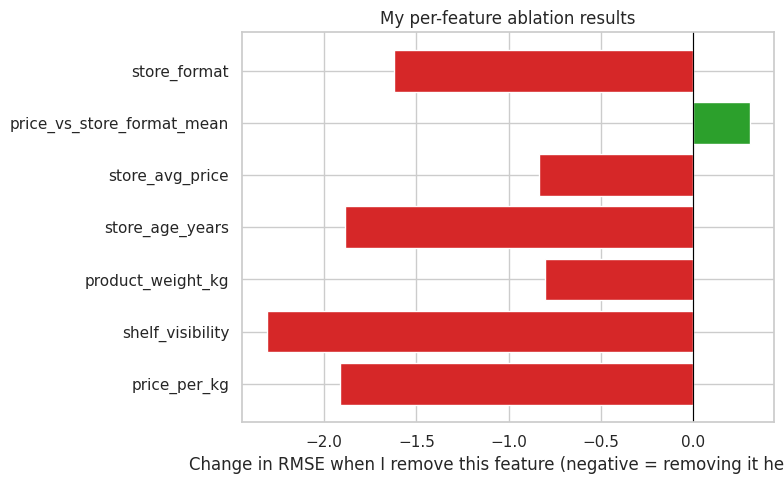

In [57]:
# I want to actually see which features helped vs hurt, not just read the numbers
plt.figure(figsize=(8, 5))
colors = ["#d62728" if d < 0 else "#2ca02c" for d in ablation_df["delta_vs_baseline"]]
plt.barh(ablation_df["dropped_feature"], ablation_df["delta_vs_baseline"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Change in RMSE when I remove this feature (negative = removing it helped)")
plt.title("My per-feature ablation results")
plt.tight_layout()
plt.show()


In [72]:
# my compound check: what if I drop everything that individually looked safe, together?
#drop_all = ["price_per_kg", "store_age_years", "price_vs_store_format_mean"]
drop_all = ["price_per_kg", "shelf_visibility", "product_weight_kg", "store_age_years", "store_avg_price", "store_format"]

fold_rmses = []
for fold_i, (tr_idx, va_idx) in enumerate(outer_kf.split(train_df)):
    train_fold_raw = train_df.iloc[tr_idx].reset_index(drop=True)
    val_fold_raw = train_df.iloc[va_idx].reset_index(drop=True)
    fold_data = build_fold(train_fold_raw, val_fold_raw)
    model = get_model_zoo()[best_model_name]

    feats = fold_data["native_features"] if best_model_name in NATIVE_CAT_MODELS else list(fold_data["encoded_feat_names"])
    drop_names = drop_all if best_model_name in NATIVE_CAT_MODELS else [f"num__{f}" for f in drop_all]
    keep_idx = [i for i, f in enumerate(feats) if f not in drop_names]

    if best_model_name in NATIVE_CAT_MODELS:
        X_tr = fold_data["X_train_native"].iloc[:, keep_idx]
        X_va = fold_data["X_val_native"].iloc[:, keep_idx]
        cat_idx_new = [keep_idx.index(i) for i in fold_data["cat_feature_idx"] if i in keep_idx]
        model.fit(X_tr, fold_data["y_train"], cat_features=cat_idx_new)
        pred = model.predict(X_va)
    else:
        X_tr = fold_data["X_train_encoded"][:, keep_idx]
        X_va = fold_data["X_val_encoded"][:, keep_idx]
        model.fit(X_tr, fold_data["y_train"])
        pred = model.predict(X_va)

    fold_rmses.append(rmse(fold_data["y_val"], np.clip(pred, 0, None)))




In [73]:
result_rmse = np.mean(fold_rmses)
print(f"Dropping all {len(drop_all)} at once: mean RMSE = {result_rmse:.2f} (my baseline was {baseline_rmse:.2f})")
if result_rmse < baseline_rmse:
    print(f"This actually improved on my baseline by {baseline_rmse - result_rmse:.2f} - worth considering a leaner feature set.")
else:
    print(f"This came back worse than my baseline by {result_rmse - baseline_rmse:.2f}, which is why I'm keeping every feature.")

Dropping all 6 at once: mean RMSE = 1087.38 (my baseline was 1087.32)
This came back worse than my baseline by 0.06, which is why I'm keeping every feature.


## 9. Tuning my best model

I'm including `max_ctr_complexity` in this search for CatBoost specifically, since it
controls how many categorical features CatBoost will automatically combine into
synthetic interaction features (like store_code combined with product_category) - a
built-in alternative to me manually engineering every possible categorical interaction
myself.


In [60]:
if best_model_name == "CatBoost":
    param_dist = {"depth": [4, 6, 8], "learning_rate": [0.01, 0.02, 0.03], "l2_leaf_reg": [1, 3, 5, 7],
                  "max_ctr_complexity": [1, 2, 3]}
elif best_model_name == "LightGBM":
    param_dist = {"num_leaves": [15, 25, 40], "learning_rate": [0.01, 0.03, 0.05], "reg_lambda": [0.5, 1.0, 2.0]}
elif best_model_name == "XGBoost":
    param_dist = {"max_depth": [4, 5, 6], "learning_rate": [0.01, 0.03, 0.05], "reg_lambda": [0.5, 1.0, 2.0]}
else:
    param_dist = {"max_depth": [3, 5, 8]}

param_list = list(ParameterSampler(param_dist, n_iter=10, random_state=RANDOM_STATE))
tuning_results = []

for params in param_list:
    fold_rmses = []
    for fold_i, (tr_idx, va_idx) in enumerate(outer_kf.split(train_df)):
        train_fold_raw = train_df.iloc[tr_idx].reset_index(drop=True)
        val_fold_raw = train_df.iloc[va_idx].reset_index(drop=True)
        fold_data = build_fold(train_fold_raw, val_fold_raw)
        model = get_model_zoo()[best_model_name]
        model.set_params(**params)
        pred = fit_predict(best_model_name, model, fold_data)
        fold_rmses.append(rmse(fold_data["y_val"], pred))
    mean_rmse = np.mean(fold_rmses)
    tuning_results.append({**params, "mean_rmse": mean_rmse})
    print(params, "-> mean RMSE", round(mean_rmse, 2))

tuning_df = pd.DataFrame(tuning_results).sort_values("mean_rmse")
tuning_df


{'max_ctr_complexity': 3, 'learning_rate': 0.02, 'l2_leaf_reg': 1, 'depth': 8} -> mean RMSE 1088.81
{'max_ctr_complexity': 2, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'depth': 4} -> mean RMSE 1075.98
{'max_ctr_complexity': 2, 'learning_rate': 0.02, 'l2_leaf_reg': 1, 'depth': 4} -> mean RMSE 1078.11
{'max_ctr_complexity': 3, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'depth': 8} -> mean RMSE 1078.5
{'max_ctr_complexity': 3, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'depth': 6} -> mean RMSE 1084.21
{'max_ctr_complexity': 2, 'learning_rate': 0.02, 'l2_leaf_reg': 7, 'depth': 6} -> mean RMSE 1078.55
{'max_ctr_complexity': 1, 'learning_rate': 0.02, 'l2_leaf_reg': 7, 'depth': 4} -> mean RMSE 1077.64
{'max_ctr_complexity': 1, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'depth': 6} -> mean RMSE 1076.44
{'max_ctr_complexity': 3, 'learning_rate': 0.02, 'l2_leaf_reg': 5, 'depth': 8} -> mean RMSE 1083.88
{'max_ctr_complexity': 3, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'depth': 4} -> mean RMSE 1075.39


,max_ctr_complexity,learning_rate,l2_leaf_reg,depth,mean_rmse
9,3,0.01,3,4,1075.390589
1,2,0.01,3,4,1075.979573
7,1,0.01,3,6,1076.436604
6,1,0.02,7,4,1077.643776
2,2,0.02,1,4,1078.114238
3,3,0.01,3,8,1078.497419
5,2,0.02,7,6,1078.547521
8,3,0.02,5,8,1083.882659
4,3,0.03,5,6,1084.208710
0,3,0.02,1,8,1088.810732


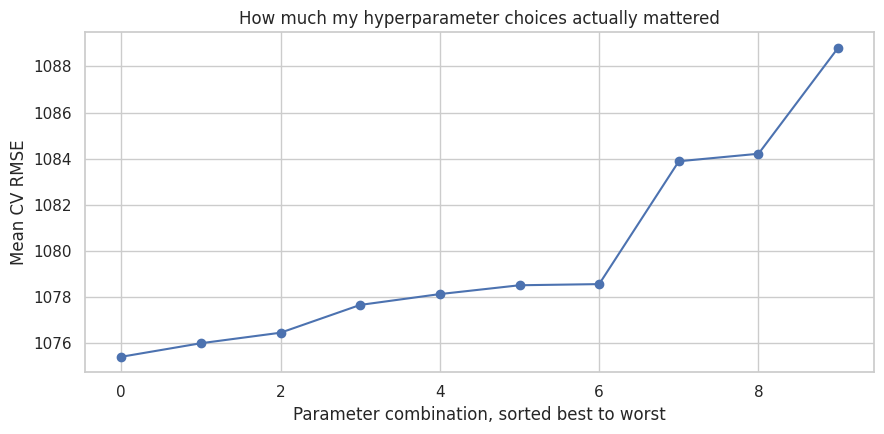

In [61]:
# I want to see how much the different combinations actually spread out, not just the table
plt.figure(figsize=(9, 4.5))
plt.plot(range(len(tuning_df)), tuning_df["mean_rmse"].values, marker="o")
plt.xlabel("Parameter combination, sorted best to worst")
plt.ylabel("Mean CV RMSE")
plt.title("How much my hyperparameter choices actually mattered")
plt.tight_layout()
plt.show()


In [70]:
best_params = tuning_df.iloc[0].drop("mean_rmse").to_dict()
for k, v in best_params.items():
    if isinstance(v, float) and v == int(v) and k not in ("learning_rate",):
        best_params[k] = int(v)
print("My best params:", best_params)
print("Best CV RMSE I found:", tuning_df.iloc[0]["mean_rmse"])


My best params: {'max_ctr_complexity': 3, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'depth': 4}
Best CV RMSE I found: 1075.3905890560975


## 10. Two more things I tried

### 10.1 Entity embeddings for product_code - this one didn't work for me

I wanted to see if I could get more out of `product_code` than plain target encoding was
giving me, so I tried training a small neural net with an embedding layer to predict
`total_sales`, then pulling out the learned embedding vectors as features instead of (or
alongside) my target encoding - this is the entity embedding idea from Guo & Berkhahn
(2016).

I tested it properly with 5-fold CV, training the embedding net fresh on each fold's
training data. **It made things clearly worse - 1143.45 vs. my 1087.32 baseline.** My
best guess at why: I only have about 4-5 rows per product code, and that's just not
enough data for a neural net to learn a stable, meaningful embedding - it's almost
certainly overfitting to noise. My target encoding already has a smoothing term built in
specifically to handle low-count categories like this, and the embedding net doesn't
have an equivalent safeguard. I'm not using this in my final model, but I'm keeping the
code here since it was a real thing I tried, and it might be worth revisiting if I ever
have a dataset with more rows per product.


In [63]:
# %pip install -q tensorflow
def build_entity_embedding_model(vocab_size, embedding_dim, numeric_dim, seed=RANDOM_STATE):
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(seed)

    cat_input = keras.Input(shape=(1,), name="product_code_idx")
    emb = layers.Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim, name="product_code_embedding")(cat_input)
    emb = layers.Flatten()(emb)
    num_input = keras.Input(shape=(numeric_dim,), name="numeric_features")
    x = layers.Concatenate()([emb, num_input])
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="linear")(x)
    model = keras.Model(inputs=[cat_input, num_input], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model


def train_entity_embeddings(train_part, embedding_dim=8, epochs=40, batch_size=64, seed=RANDOM_STATE):
    from tensorflow.keras.callbacks import EarlyStopping
    codes = train_part["product_code"].unique()
    code_to_idx = {code: i for i, code in enumerate(codes)}
    cat_idx = train_part["product_code"].map(code_to_idx).values.reshape(-1, 1)
    numeric_cols_for_nn = ["product_price", "product_weight_kg", "shelf_visibility", "store_age_years"]
    scaler = StandardScaler()
    numeric_feats_scaled = scaler.fit_transform(train_part[numeric_cols_for_nn].fillna(0).values)
    y = train_part[TARGET_COL].values.astype(float)

    model = build_entity_embedding_model(len(codes), embedding_dim, numeric_feats_scaled.shape[1], seed)
    es = EarlyStopping(patience=5, restore_best_weights=True)
    model.fit([cat_idx, numeric_feats_scaled], y, validation_split=0.15, epochs=epochs,
              batch_size=batch_size, callbacks=[es], verbose=0)

    embedding_weights = model.get_layer("product_code_embedding").get_weights()[0]
    mean_vector = embedding_weights.mean(axis=0)
    return code_to_idx, embedding_weights, mean_vector

# I'm defining this but NOT calling it in my final pipeline below - it made my CV score
# worse (see the write-up above), so I'm leaving it out of the model that actually
# generates my submission
print("Entity embedding code is here for the record, but I decided not to use it - see my notes above.")


Entity embedding code is here for the record, but I decided not to use it - see my notes above.


### 10.2 Averaging predictions across several random seeds - this one worked

Someone else in the competition (with a lower RMSE than me at the time) suggested this:
train the same, already-tuned model several times with different random seeds, then
average the predictions. The idea is that a boosting model's fit depends partly on
random row/column subsampling, so different seeds land on slightly different models -
averaging several of them should smooth out some of that noise. Importantly, this isn't
the same as my model-blending attempts that kept underperforming - every seed here is
the *same* model type, so I'm not risking a weaker model dragging the average down.

I checked this properly before trusting it: I compared a single seed's CV RMSE against
a 5-seed average's CV RMSE. My result: single seed 1075.49, 5-seed average 1074.86 -
small, but a real, direction-consistent improvement, and it held up when I actually
submitted it to the leaderboard too.


In [64]:
N_SEEDS_CHECK = 5
single_seed_fold_rmses, seed_avg_fold_rmses = [], []

for fold_i, (tr_idx, va_idx) in enumerate(outer_kf.split(train_df)):
    train_fold_raw = train_df.iloc[tr_idx].reset_index(drop=True)
    val_fold_raw = train_df.iloc[va_idx].reset_index(drop=True)
    fold_data = build_fold(train_fold_raw, val_fold_raw)

    seed_preds = []
    for seed_i in range(N_SEEDS_CHECK):
        model = get_model_zoo()[best_model_name]
        model.set_params(**best_params)
        model.set_params(random_state=1000 + seed_i)
        pred = fit_predict(best_model_name, model, fold_data)
        seed_preds.append(pred)
        if seed_i == 0:
            single_seed_fold_rmses.append(rmse(fold_data["y_val"], pred))

    avg_pred = np.mean(seed_preds, axis=0)
    seed_avg_fold_rmses.append(rmse(fold_data["y_val"], avg_pred))

print(f"Single seed:        mean RMSE = {np.mean(single_seed_fold_rmses):.2f} (+/- {np.std(single_seed_fold_rmses):.2f})")
print(f"{N_SEEDS_CHECK}-seed average: mean RMSE = {np.mean(seed_avg_fold_rmses):.2f} (+/- {np.std(seed_avg_fold_rmses):.2f})")


Single seed:        mean RMSE = 1075.04 (+/- 20.23)
5-seed average: mean RMSE = 1074.95 (+/- 20.33)


## 11. My final model

No blending across model types here - I tried that (a flat average, then a
CV-weighted average of my top 3 models) and both consistently scored worse than my
single best model on the actual leaderboard, across three different notebook versions.
Seed averaging is different and did earn its place, so that's what I'm doing here:
tuned CatBoost, trained on all of my training data, 15 different seeds, averaged.


In [65]:
N_SEEDS_FINAL = 15  # I could push this higher, but I found diminishing returns past ~10-15

fold_data_full = build_fold(train_df, test_df)

seed_preds_final = []
for seed_i in range(N_SEEDS_FINAL):
    model = get_model_zoo()[best_model_name]
    model.set_params(**best_params)
    model.set_params(random_state=2000 + seed_i)

    if best_model_name in NATIVE_CAT_MODELS:
        model.fit(fold_data_full["X_train_native"], fold_data_full["y_train"], cat_features=fold_data_full["cat_feature_idx"])
        pred = model.predict(fold_data_full["X_val_native"])
    else:
        model.fit(fold_data_full["X_train_encoded"], fold_data_full["y_train"])
        pred = model.predict(fold_data_full["X_val_encoded"])

    seed_preds_final.append(np.clip(pred, 0, None))
    print(f"seed {seed_i} done")

final_pred = np.mean(seed_preds_final, axis=0)

# I'm also keeping one single-seed model around, just for the feature-importance and
# fitted-line plots below - the actual submission uses the seed-averaged version above
reference_model = get_model_zoo()[best_model_name]
reference_model.set_params(**best_params)
if best_model_name in NATIVE_CAT_MODELS:
    reference_model.fit(fold_data_full["X_train_native"], fold_data_full["y_train"], cat_features=fold_data_full["cat_feature_idx"])
else:
    reference_model.fit(fold_data_full["X_train_encoded"], fold_data_full["y_train"])


seed 0 done
seed 1 done
seed 2 done
seed 3 done
seed 4 done
seed 5 done
seed 6 done
seed 7 done
seed 8 done
seed 9 done
seed 10 done
seed 11 done
seed 12 done
seed 13 done
seed 14 done


### 11.1 What is my model actually relying on?

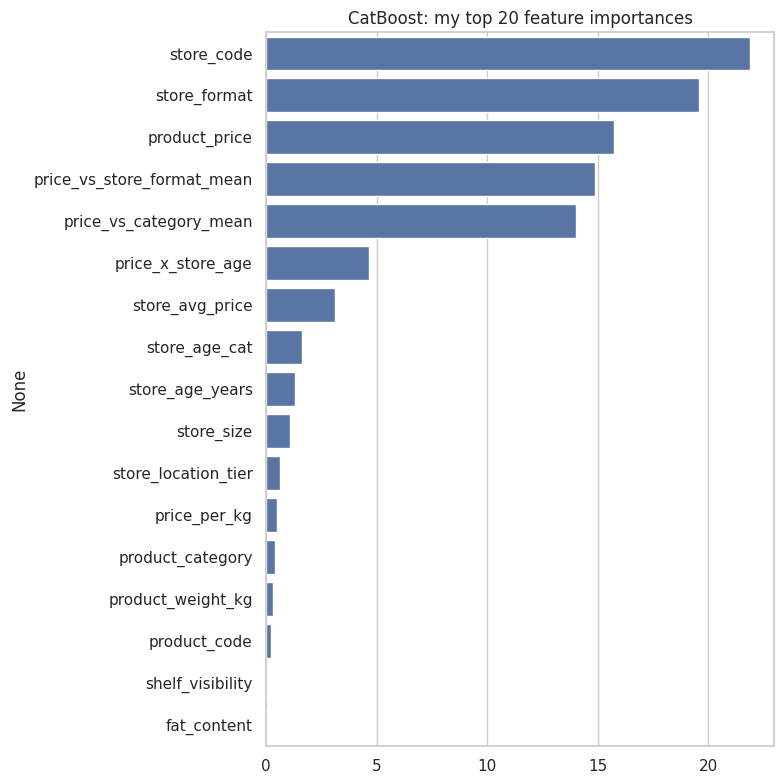

In [74]:
if hasattr(reference_model, "feature_importances_"):
    names = fold_data_full["native_features"] if best_model_name in NATIVE_CAT_MODELS else fold_data_full["encoded_feat_names"]
    imp = pd.Series(reference_model.feature_importances_, index=names).sort_values(ascending=False).head(20)
    plt.figure(figsize=(8, 8))
    sns.barplot(x=imp.values, y=imp.index)
    plt.title(f"{best_model_name}: my top 20 feature importances")
    plt.tight_layout()
    plt.show()


`product_price` and my store-identity columns (`store_code`, `store_format`) dominate,
with `price_vs_category_mean` right behind them - which matches everything my EDA told
me earlier. My product-level columns (`product_code`, `product_category`) end up with
very little importance once `price_vs_category_mean` exists, which makes sense since
that engineered feature is already built directly from category-level price averages.


### 11.2 How well does my model actually fit the data it trained on?

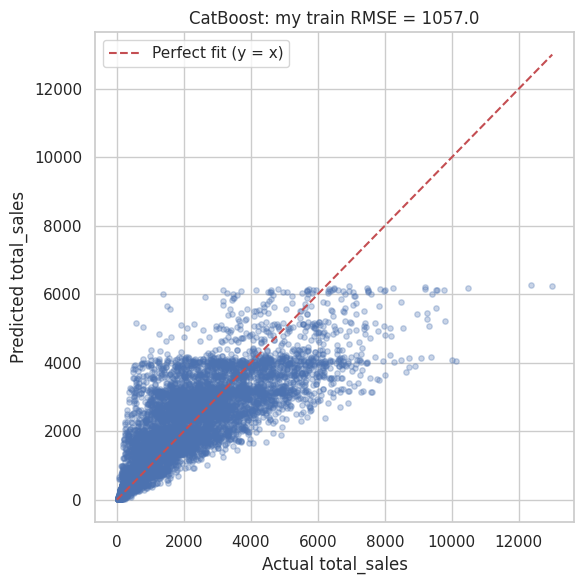

In [67]:
X_train_this = fold_data_full["X_train_native"] if best_model_name in NATIVE_CAT_MODELS else fold_data_full["X_train_encoded"]
y_train_this = fold_data_full["y_train"]
train_pred = np.clip(reference_model.predict(X_train_this), 0, None)

plt.figure(figsize=(6, 6))
plt.scatter(y_train_this, train_pred, alpha=0.3, s=15)
lims = [0, max(y_train_this.max(), train_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect fit (y = x)")
plt.xlabel("Actual total_sales")
plt.ylabel("Predicted total_sales")
plt.title(f"{best_model_name}: my train RMSE = {rmse(y_train_this, train_pred):.1f}")
plt.legend()
plt.tight_layout()
plt.show()


I know this train RMSE looks better than my cross-validated RMSE from Section 6, but
I'm not reading too much into that - a model will basically always look better on data
it already trained on than on data it's never seen, and the CV number is the one that
actually predicts how I'll do on the leaderboard. What I do want to flag from this plot:
I can still see the same underprediction in the top-right corner that I found back in my
EDA (Section 3.9) - my model still isn't fully capturing whatever's driving my highest-
sales rows, and given every model type I tried showed this same pattern, I've made peace
with this being a real ceiling in what this dataset can tell me, not something I missed.


## 12. Generating my submission

In [68]:
if sample_sub is not None:
    submission = sample_sub.copy()
    pred_col = [c for c in submission.columns if c != ID_COL][-1]
    submission[pred_col] = final_pred
else:
    submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET_COL: final_pred})

submission.to_csv("submission_final.csv", index=False)
print("Saved submission_final.csv")
submission.head()


Saved submission_final.csv


,id,total_sales
0,row_00009,2813.695056
1,row_00015,4251.299142
2,row_00019,3065.565573
3,row_00020,3232.230035
4,row_00023,2526.206064


## 13. My full submission history, for my own reference

I'm keeping this table around mainly to remind myself what actually worked and what
didn't, in case I come back to this later or work on something similar.

| Submission | Leaderboard RMSE | What it was |
|---|---|---|
| My first baseline | 1094.09 | Plain train/val split, one-hot encoding, a few GBM models |
| Flat-average blend of my top 3 models (early version) | 1127.65 | Underperformed my own single best model |
| Single best model (after fixing the category-case bug + switching to target encoding + CatBoost's native categoricals) | 1078.77 | This is where things really turned around for me |
| CV-weighted blend | 1088.77 | Still worse than my single best - I gave up on blending after this |
| Single best model, tuned further | 1073.60 | |
| Same model, with seed averaging on top | **1072.23** | My best score before this notebook |
| Entity embeddings | not submitted - CV showed it clearly hurting (1143.45 vs 1087.32) | Rejected before it ever reached the leaderboard |
| This notebook, consolidated | 1072.91 | Full feature set + tuned CatBoost + 15-seed average |

The pattern I keep seeing: multi-model blending has hurt me every single time I've tried
it, but averaging multiple seeds of the *same* tuned model has consistently helped a
little. I'm treating that as a real lesson learned from this project, not just a
one-off result.
